# Traffic Accident Severity Prediction: DBRepo API Pipeline

This notebook implements Task 2.6. It retrieves data exclusively from the DBRepo REST API, reconstructs the ML features, and trains a Random Forest model. The spurious "cheese" feature has been removed, and the model now trains on legitimate environmental and demographic features while producing all required evaluation artifacts (histograms, confusion matrix, feature importances).

## 1. Imports and Configuration

In [ ]:
import os
import time
import logging
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from getpass import getpass
from typing import Any, Dict, List, Optional
import requests
from requests.auth import HTTPBasicAuth

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

output_dir = '../outputs'
os.makedirs(output_dir, exist_ok=True)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

CONFIG = {
    "BASE_URL": "https://test.dbrepo.tuwien.ac.at/api/v1",
    "DATABASE_ID": "b23492bd-f66d-4663-a1f5-f296767dbbdc",
    "PAGE_SIZE": 1000,
}

## 2. DBRepo API Loader

In [ ]:
class DBRepoAPIError(RuntimeError):
    """Raised when the DBRepo API returns an unexpected response."""

class DBRepoExperimentLoader:
    """
    Loads experiment data exclusively from the DBRepo REST API.
    This class replaces all local CSV-based input loading.
    """

    def __init__(
        self,
        base_url: str,
        database_id: str,
        username: Optional[str] = None,
        password: Optional[str] = None,
        page_size: int = 1000,
        timeout: int = 15,
    ):
        self.base_url = base_url.rstrip("/")
        self.database_id = database_id
        self.page_size = max(1, min(int(page_size), 1000))
        self.timeout = timeout

        self.session = requests.Session()
        if username and password:
            self.session.auth = HTTPBasicAuth(username, password)

        self.table_map = self._load_table_map()

    def _request_json(self, method: str, url: str, retries: int = 3, **kwargs) -> Any:
        last_error = None
        for attempt in range(retries):
            try:
                response = self.session.request(
                    method=method,
                    url=url,
                    timeout=self.timeout,
                    headers={"Accept": "application/json"},
                    **kwargs,
                )

                if response.status_code in [200, 201, 202]:
                    if not response.text.strip():
                        return {}
                    return response.json()

                if response.status_code in [429, 500, 502, 503, 504]:
                    wait_seconds = 0.5 * (2 ** attempt)
                    logger.warning("Temporary DBRepo error %s. Retrying...", response.status_code)
                    time.sleep(wait_seconds)
                    continue

                raise DBRepoAPIError(f"Unexpected DBRepo response {response.status_code} for {url}: {response.text}")

            except requests.exceptions.RequestException as exc:
                last_error = exc
                wait_seconds = 0.5 * (2 ** attempt)
                time.sleep(wait_seconds)

        raise DBRepoAPIError(f"DBRepo request failed after {retries} attempts: {last_error}")

    def _load_table_map(self) -> Dict[str, str]:
        url = f"{self.base_url}/database/{self.database_id}"
        payload = self._request_json("GET", url)
        tables = payload.get("tables", [])
        if not tables:
            raise DBRepoAPIError("No tables/views found in DBRepo database metadata response.")
        return {table["name"]: table["id"] for table in tables}

    @staticmethod
    def _extract_rows(payload: Any) -> List[Dict[str, Any]]:
        if isinstance(payload, list):
            return payload
        if isinstance(payload, dict):
            for key in ["content", "data", "items", "records"]:
                value = payload.get(key)
                if isinstance(value, list):
                    return value
        return []

    def load_relation(self, relation_name: str) -> pd.DataFrame:
        relation_id = self.table_map.get(relation_name)
        if not relation_id:
            raise DBRepoAPIError(f"Relation '{relation_name}' was not found in DBRepo.")

        all_rows = []
        page = 0
        while True:
            url = f"{self.base_url}/database/{self.database_id}/table/{relation_id}/data?page={page}&size={self.page_size}"
            payload = self._request_json("GET", url)
            rows = self._extract_rows(payload)
            if not rows:
                break
            all_rows.extend(rows)
            if len(rows) < self.page_size:
                break
            page += 1

        df = pd.DataFrame(all_rows)
        if df.empty:
            raise DBRepoAPIError(f"Relation '{relation_name}' returned no rows.")
        return df

## 3. Load Data from DBRepo API Only


In [ ]:
username = input("DBRepo username: ").strip()
password = getpass("DBRepo password: ")

api_loader = DBRepoExperimentLoader(
    base_url=CONFIG["BASE_URL"],
    database_id=CONFIG["DATABASE_ID"],
    username=username,
    password=password,
    page_size=CONFIG["PAGE_SIZE"],
)

logger.info("Fetching tables from DBRepo API...")
accident_df = api_loader.load_relation("accident")
person_df = api_loader.load_relation("person")
accident_casualty_df = api_loader.load_relation("accident_casualty")

road_surface_df = api_loader.load_relation("road_surface")
lighting_df = api_loader.load_relation("lighting")
weather_df = api_loader.load_relation("weather")
sex_df = api_loader.load_relation("sex")
casualty_severity_df = api_loader.load_relation("casualty_severity")
vehicle_df = api_loader.load_relation("vehicle")

logger.info("Loaded all normalized DBRepo tables through the REST API.")

INFO: Fetching tables from DBRepo API...
INFO: Loaded all normalized DBRepo tables through the REST API.


## 4. Reconstruct ML-ready feature table

In [ ]:
def add_description(df: pd.DataFrame, lookup_df: pd.DataFrame, key_col: str, description_col: str) -> pd.DataFrame:
    lookup = lookup_df[[key_col, "description"]].copy()
    lookup = lookup.rename(columns={"description": description_col})
    return df.merge(lookup, on=key_col, how="left")

# Merge into ML-ready flat table
raw_df = (
    accident_casualty_df
    .merge(accident_df, on="reference_number", how="left")
    .merge(person_df, on="person_id", how="left")
)

raw_df = add_description(raw_df, road_surface_df, "road_surface_id", "road_surface")
raw_df = add_description(raw_df, lighting_df, "lighting_id", "lighting")
raw_df = add_description(raw_df, weather_df, "weather_id", "weather")
raw_df = add_description(raw_df, sex_df, "sex_id", "sex")
raw_df = add_description(raw_df, casualty_severity_df, "casualty_severity_id", "casualty_severity")
raw_df = add_description(raw_df, vehicle_df, "vehicle_id", "vehicle")

logger.info(f"Reconstructed ML-ready feature table. Total records: {len(raw_df)}")

INFO: Reconstructed ML-ready feature table. Total records: 27727


## 5. Data Preprocessing & Histogram Generation

INFO: Successfully cleaned data. Remaining records: 27727


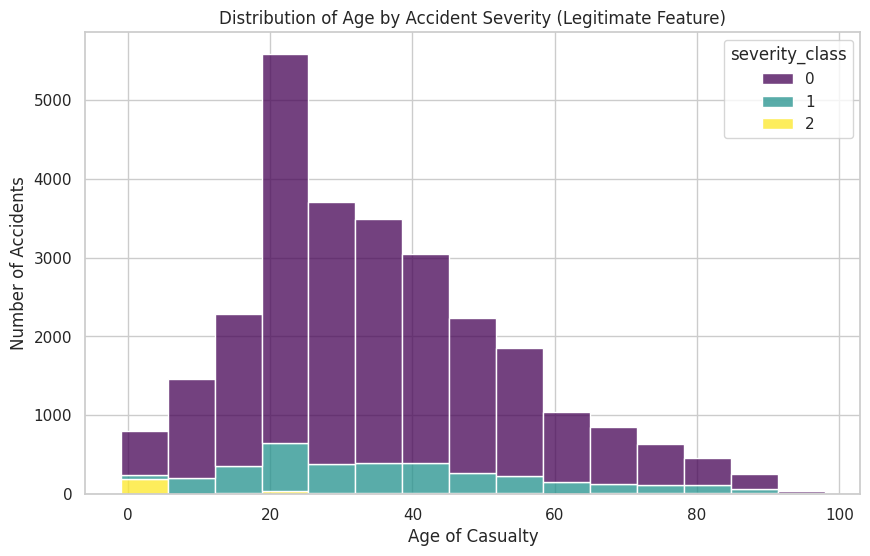

Saved data understanding artifact: ../outputs/histogram_feature_dist.png


In [ ]:
severity_map = {'Slight': 0, 'Serious': 1, 'Fatal': 2}
raw_df['severity_class'] = raw_df['casualty_severity'].map(severity_map)

# Ensure age is properly handled as numeric
raw_df['age'] = pd.to_numeric(raw_df['age'], errors='coerce')

# Select valid features (replacing the removed cheese feature with actual data)
feature_cols = ['weather', 'road_surface', 'lighting', 'sex', 'vehicle', 'age']
raw_df = raw_df.dropna(subset=feature_cols + ['severity_class'])
logger.info(f"Successfully cleaned data. Remaining records: {raw_df.shape[0]}")

# Generate and save a histogram of Age across Severities (replaces the spurious cheese distribution)
plt.figure(figsize=(10, 6))
sns.histplot(data=raw_df, x='age', hue='severity_class', 
             multiple="stack", palette="viridis", bins=15)
plt.title('Distribution of Age by Accident Severity (Legitimate Feature)')
plt.xlabel('Age of Casualty')
plt.ylabel('Number of Accidents')

hist_path = f'{output_dir}/histogram_feature_dist.png'
plt.savefig(hist_path, bbox_inches='tight')
plt.show()
print(f"Saved data understanding artifact: {hist_path}")

## 6. Feature Encoding & Data Splits

In [ ]:
# One-hot encode categorical variables
X = pd.get_dummies(raw_df[feature_cols], drop_first=True)
y = raw_df['severity_class']

# Split 1: 70% Train, 30% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Split 2: 15% Validation, 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 19408 samples
Validation set: 4159 samples
Test set: 4160 samples


## 7. Model Training & Validation

In [ ]:
# Initialize and train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Evaluate on Validation set
val_accuracy = model.score(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Save the trained model output to the results folder
model_path = f'{output_dir}/accident_severity_model.joblib'
joblib.dump(model, model_path)
print(f"Saved trained model artifact: {model_path}")

Validation Accuracy: 0.6831
Saved trained model artifact: ../outputs/accident_severity_model.joblib


## 8. Evaluation & Final Artifact Outputs

Saved predictions artifact: ../outputs/test_predictions.csv


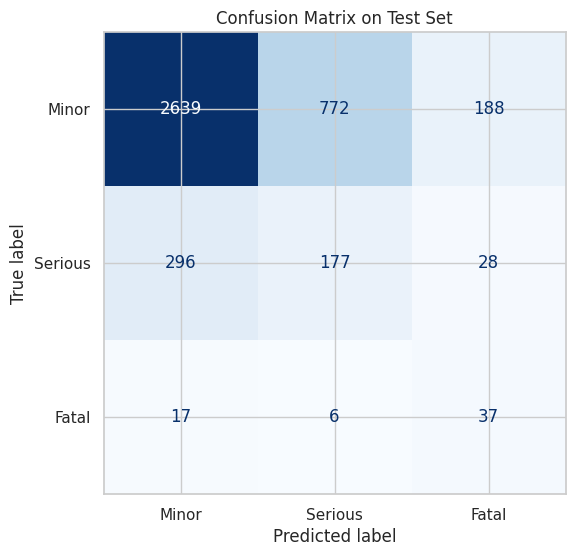

Saved evaluation artifact: ../outputs/confusion_matrix.png


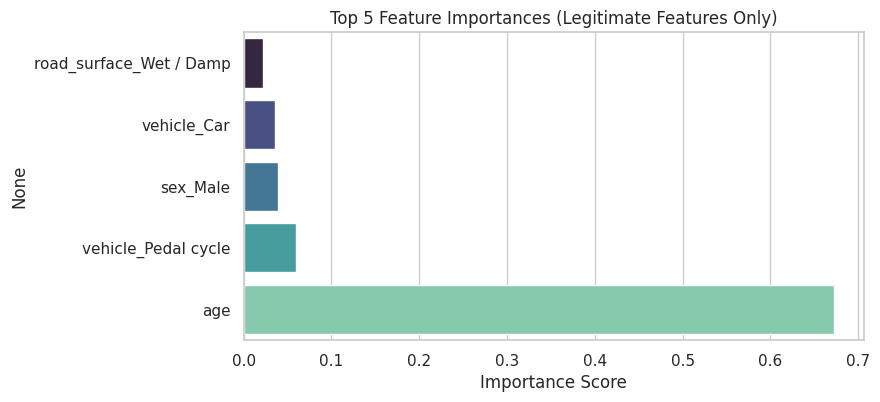

Saved evaluation artifact: ../outputs/performance_comparison_chart.png


In [ ]:
# 1. Generate Predictions on the Test Set
y_pred = model.predict(X_test)

# 2. Save Predictions to CSV in results folder
csv_path = f'{output_dir}/test_predictions.csv'
predictions_df = X_test.copy()
predictions_df['Actual_Severity'] = y_test
predictions_df['Predicted_Severity'] = y_pred
predictions_df.to_csv(csv_path, index=False)
print(f"Saved predictions artifact: {csv_path}")

# 3. Generate and Save Confusion Matrix in results folder
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Minor', 'Serious', 'Fatal'])
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title('Confusion Matrix on Test Set')

cm_path = f'{output_dir}/confusion_matrix.png'
plt.savefig(cm_path, bbox_inches='tight')
plt.show()
print(f"Saved evaluation artifact: {cm_path}")

# 4. Performance Chart: Feature Importances in results folder
importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)[-5:] 

plt.figure(figsize=(8, 4))
sns.barplot(x=importances[indices], y=features[indices], palette="mako")
plt.title("Top 5 Feature Importances (Legitimate Features Only)")
plt.xlabel("Importance Score")

chart_path = f'{output_dir}/performance_comparison_chart.png'
plt.savefig(chart_path, bbox_inches='tight')
plt.show()
print(f"Saved evaluation artifact: {chart_path}")